# Observables
Let $\tilde{S}_{iy}$ be the "raw" size of firm $i$ at year $y$, we then normalize it by dividing it with the total market size at that time
$$
S_{iy} = \frac{\tilde{S}_{iy}}{\sum_i \tilde{S}_{iy}}
$$

then we define the growth rate as
$$
g_{iy} = \ln\left(\frac{S_{iy+1}}{S_{iy}}\right) = \ln(S_{iy+1}) - \ln(S_{iy}) =  \ln(\tilde{S}_{iy+1}) - \ln(\tilde{S}_{iy}) + \left[\ln\left(\sum_i \tilde{S}_{iy}\right) -  \ln\left(\sum_i \tilde{S}_{iy+1}\right) \right]
$$
from this the growth volatility is calculated using the adjusted mean absolute deviation
$$
\sigma_i = \sqrt{\frac{\pi}{2}} \frac{1}{T_i} \sum_y |g_{iy} - \bar{g}_i|
$$

In [164]:
import numpy as np
import glv

# --- model parameters ---
N = 10000
C = 50
mu = 1
sigma = 10

# --- simulation parameters ---
tmax = 100
n_eval = 2000          # time resolution; needs to be fine enough for yearly sampling

# --- observables parameter ---
year_length = 1.0      # how many GLV time units make one "year"

In [160]:
degrees = glv.get_degree_sequence(N, C, topology="regular")
A = glv.generate_matrix(degrees, C, mu, sigma)
g = np.array(degrees, dtype=float) / C
print(f"$mu_c$: {1.0 / np.mean(g ** 2):.4f}")

$mu_c$: 1.0000


In [161]:
x0 = np.random.uniform(0.1, 1.0, N)
sol, t = glv.simulate_glv(A, x0, tmax=tmax, n_eval=n_eval)

In [162]:
# --- sample at yearly snapshots ---
year_times = np.arange(0, tmax + year_length, year_length)           # 0, 1, 2, ... tmax
year_idx   = np.searchsorted(t, year_times).clip(0, len(t) - 1)      # nearest indices
S_raw = sol[year_idx]                                                  # (n_years, N)  raw abundances

# --- normalize: S_iy = x̃_iy / Σ_i x̃_iy ---
S = S_raw / S_raw.sum(axis=1, keepdims=True)                          # (n_years, N)

# --- growth rates: g_iy = ln(S_i,y+1) - ln(S_i,y) ---
log_S = np.log(np.maximum(S, 1e-300))                                 # guard against log(0)
g = np.diff(log_S, axis=0)                                            # (n_years-1, N)

# --- per-species volatility: σ_i = sqrt(π/2) · MAD(g_i) ---
g_mean  = g.mean(axis=0)                                              # (N,)
sigma_i = np.sqrt(np.pi / 2) * np.abs(g - g_mean).mean(axis=0)        # (N,)

print(f"Years observed : {g.shape[0]}")
print(f"Mean volatility: {sigma_i.mean():.4f}")
print(f"Max volatility : {sigma_i.max():.4f}")
sol.shape, t.shape


Years observed : 50
Mean volatility: 0.0291
Max volatility : 0.1273


((3, 10000), (3,))

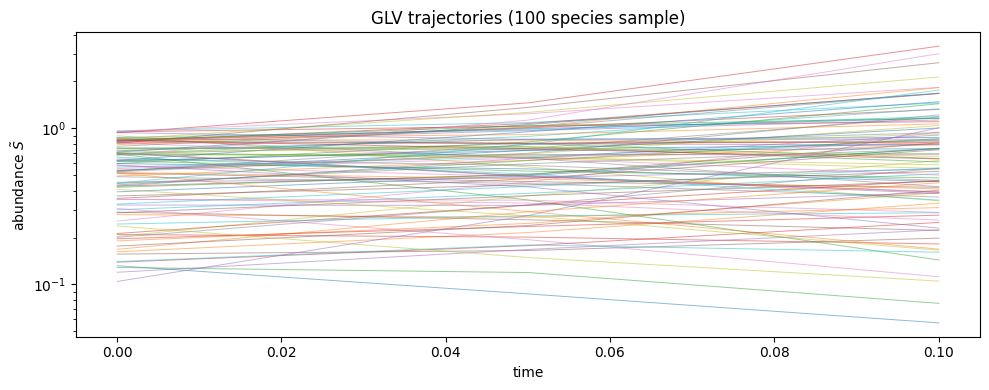

In [163]:
import matplotlib.pyplot as plt
        
sample_idx = np.random.choice(N, size=min(100, N), replace=False)

fig, ax = plt.subplots(figsize=(10, 4))
for i in sample_idx:
    ax.plot(t, sol[:, i], lw=0.7, alpha=0.5)

ax.set_xlabel("time")
ax.set_ylabel("abundance $\\tilde{S}$")
ax.set_yscale("log")
ax.set_title("GLV trajectories (100 species sample)")
plt.tight_layout()
plt.show()

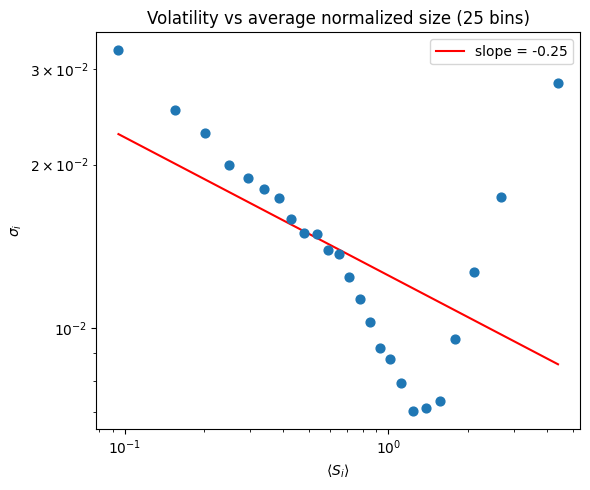

In [152]:
avg_size = S.mean(axis=0) * N  # (N,) — time-averaged normalized size per species

# --- bin companies into 25 equal-count bins by mean size ---
n_bins = 25
bin_edges = np.percentile(avg_size, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(avg_size, bin_edges[1:-1])  # (N,) — bin assignment 0..n_bins-1

bin_x = np.array([avg_size[bin_idx == b].mean() for b in range(n_bins)])
bin_y = np.array([sigma_i[bin_idx == b].mean() for b in range(n_bins)])

# linear fit in log-log space on binned data
log_x = np.log(bin_x)
log_y = np.log(bin_y)
slope, intercept = np.polyfit(log_x, log_y, 1)

x_line = np.logspace(np.log10(bin_x.min()), np.log10(bin_x.max()), 200)
y_line = np.exp(intercept) * x_line ** slope

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(bin_x, bin_y, s=40, zorder=3)
ax.plot(x_line, y_line, color="red", lw=1.5, label=f"slope = {slope:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\langle S_i \rangle$")
ax.set_ylabel(r"$\sigma_i$")
ax.set_title("Volatility vs average normalized size (25 bins)")
ax.legend()
plt.tight_layout()
plt.show()


![](images/volatility_vs_size_bm.png)